# 03 Preprocseeing

- Pixel = 1: area is potentially suitable (all 20 criteria passed)
- Pixel = 0: area is excluded (at least 1 criterion violated)

**→ Continue with:** `03_preprocessing_wlc.ipynb` → Calculate suitability factors

**Input:**
```
data/processed/constraints/constraint_mask_s2.tif
data/processed/dem/dem_gr_25m.tif, slope_gr_25m.tif, aspect_gr_25m.tif
data/raw/solar/                    BFE solar radiation (30°, 75°)
data/raw/snow/                     SPASS snow cover
data/raw/tlm3d/                    swissTLM3D (Roads, Power, dams, buildings)
```

**Output:**
```
data/processed/criteria/f01–f10_*.tif     (10 normalized suitability factors [0, 1])
data/processed/distances/dist_*.tif       (Distance rasters)
```


This notebook is independent of 01/02a — any binary mask suffices as input.

## 1. Setup

In [ ]:
# Import required libraries
from pathlib import Path                                                   # Cross-platform file path handling
import geopandas as gpd                                                    # Geospatial data manipulation (shapefiles, GeoJSON)
import numpy as np                                                         # Numerical computing
import pandas as pd                                                        # Tabular data analysis
import rasterio                                                            # Read/write raster data (GeoTIFF, etc.)
from rasterio.enums import Resampling                                      # Resampling methods for raster reprojection
from rasterio.transform import from_bounds                                 # Create georeferencing transform from bounds
from rasterio.features import rasterize                                    # Convert vector geometries to raster
from rasterio.warp import reproject                                        # Reproject raster to target CRS/grid
from scipy.ndimage import distance_transform_edt                           # Euclidean distance transform for buffering
import fiona                                                               # Read/write vector data formats
import matplotlib.pyplot as plt                                            # Data visualization
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")                                          # Suppress non-critical warnings for cleaner output

#Define data paths
RAW  = Path("../data/raw")                                                # Raw input data directory
PROC = Path("../data/processed")                                           # Processed data directory
OUT  = Path("../outputs/figures")                                          # Figure output directory
for d in [PROC / "criteria", PROC / "distances", OUT]:
    d.mkdir(parents=True, exist_ok=True)  # Create output subdirectories if missing

#Constants
CRS    = "EPSG:2056"                                                       # Target CRS (LV95, Swiss standard)
RES    = 25                                                                # Pixel resolution [m]
NODATA = -9999.0                                                           # NoData value for missing/invalid pixels

print("✓ Setup OK")

✓ Setup OK


## 2.  Load Constraint Mask & Reference Raster

In [2]:
print("=== Load Constraint Mask & Reference Raster ===\n")

#Constraint mask (from 02a)
mask_path = PROC / "constraints/constraint_mask_s2.tif"  # Path to combined exclusion mask
with rasterio.open(mask_path) as src:  # Open raster file
    constraint_mask = src.read(1)                                          # Binary mask (0/1): 1 = suitable, 0 = excluded
    transform = src.transform                                              # Affine transformation (georeference)
    ref_profile = src.profile.copy()                                       # Reference metadata profile for outputs
    ref_profile.update(dtype="float32", nodata=NODATA)  # Update output data type
    height, width = constraint_mask.shape                                  # Raster dimensions [pixels]

#DEM derivatives (from 02a)
with rasterio.open(PROC / "dem/dem_gr_25m.tif") as src:  # Open elevation raster
    dem = src.read(1)                                                      # Elevation [m]
with rasterio.open(PROC / "dem/slope_gr_25m.tif") as src:  # Open slope raster
    slope = src.read(1)                                                    # Slope gradient [°]
with rasterio.open(PROC / "dem/aspect_gr_25m.tif") as src:  # Open aspect raster
    aspect = src.read(1)                                                   # Aspect direction [0–360°]

#Validity mask
valid = (dem != NODATA) & (constraint_mask == 1)                           # Valid pixels: suitable AND DEM available
print(f"  Constraint mask: {constraint_mask.sum():,} pixels ({constraint_mask.sum()*RES*RES/1e6:.0f} km²)")
print(f"  Raster: {width}×{height} @ {RES}m")

=== Load Constraint Mask & Reference Raster ===

  Constraint mask: 626,229 pixels (391 km²)
  Raster: 5641×4010 @ 25m


## Helper Functions

In [3]:
def normalize_linear(data, low, high, invert=False):
    """Linear min-max normalization to [0, 1]."""
    out = np.full_like(data, NODATA)  # Initialize output array
    m = valid & (data != NODATA)                                           # Valid pixels: suitable AND data available
    vals = np.clip((data[m] - low) / (high - low), 0, 1)                  # Normalize: (x - min) / (max - min), clip to [0,1]
    out[m] = 1 - vals if invert else vals                                  # Apply inversion if requested (closer = higher for distances)
    return out


def normalize_piecewise(data, breakpoints, values):
    """Piecewise linear normalization via interpolation."""
    out = np.full_like(data, NODATA)  # Initialize output array
    m = valid & (data != NODATA)                                           # Valid pixels: suitable AND data available
    out[m] = np.interp(data[m], breakpoints, values)                       # Interpolate: map data values to score values at breakpoints
    return out


def save_criterion(data, name):
    """Saves a normalized criterion as GeoTIFF."""
    path = PROC / f"criteria/{name}.tif"  # Output file path
    with rasterio.open(path, "w", **ref_profile) as dst:  # Create GeoTIFF
        dst.write(data, 1)                                                 # Write data to band 1
    v = data[valid & (data != NODATA)]                                     # Extract valid suitability scores
    print(f"  {name}: {v.min():.3f}–{v.max():.3f} (mean {v.mean():.3f})")  # Print statistics


def rasterize_to_grid(gdf, burn=1):
    """Rasterizes vector data to the reference grid."""
    shapes = [(g, burn) for g in gdf.to_crs(CRS).geometry if g is not None]  # Generate (geometry, value) tuples
    if not shapes:  # If no geometries
        return np.zeros((height, width), dtype=np.uint8)  # Return empty raster (all zeros)
    return rasterize(shapes, out_shape=(height, width), transform=transform, fill=0, dtype=np.uint8)  # Rasterize


def compute_distance(binary_raster, name):
    """Computes Euclidean distance to binary raster features."""
    dist = distance_transform_edt(                                         # Euclidean distance transform
        (binary_raster == 0).astype(float), sampling=(RES, RES)  # Distance from pixels = 1 to pixels = 0
    ).astype(np.float32)
    with rasterio.open(PROC / f"distances/{name}.tif", "w", **ref_profile) as dst:  # Save distance raster
        dst.write(dist, 1)                                                 # Write to band 1
    print(f"  {name}: max {dist[valid].max():.0f} m")  # Print statistics
    return dist


print("✓ Functions defined")

✓ Functions defined


## 3. Data Check — WLC Datasets
Quality control of datasets required ONLY for WLC (not for constraints).

In [4]:
print("=== Check WLC Datasets ===\n")

#BFE Solar (4 tilt angles)
for deg in ["0", "30", "75", "90"]:  # Check each available tilt angle
    parent = RAW / "solar" / f"solarenergie-einstrahlung_{deg}_grad_2056.gpkg"  # Expected path
    gpkg = next(parent.glob("*.gpkg"), None) if parent.is_dir() else (parent if parent.exists() else None)  # Find GeoPackage
    if gpkg:  # If file exists
        gdf = gpd.read_file(gpkg, rows=slice(0, 1))                       # Read first row for CRS check
        print(f"  BFE Solar {deg}°: ✓ CRS={gdf.crs}")  # Print confirmation
    else:  # If file missing
        print(f"  BFE Solar {deg}°: ⚠ MISSING")  # Print warning

#SPASS Snow
spass = sorted((RAW / "snow").glob("**/*.nc"))  # Search for NetCDF files
print(f"  SPASS Snow: {'✓ ' + spass[0].name if spass else '⚠ MISSING'}")  # Print status

#swissTLM3D
tlm_path = RAW / "tlm3d/swisstlm3d_2026-02-24_2056_5728.gpkg"  # Expected path
if tlm_path.is_dir():                                                     # If path is directory
    tlm_path = next(tlm_path.glob("*.gpkg"))  # Find GeoPackage inside
print(f"  swissTLM3D: {'✓' if tlm_path.exists() else '⚠ MISSING'}")  # Print status

=== Check WLC Datasets ===

  BFE Solar 0°: ✓ CRS=EPSG:2056
  BFE Solar 30°: ✓ CRS=EPSG:2056
  BFE Solar 75°: ✓ CRS=EPSG:2056
  BFE Solar 90°: ✓ CRS=EPSG:2056
  SPASS Snow: ✓ SWECLQMD_ch01h.swiss.lv95_WY_1962_2023.nc
  swissTLM3D: ✓


## 4. BFE Solar → Raster

In [5]:
print("=== BFE Solar → Raster ===\n")

#Bounding Box of reference raster
bbox = (transform.c, transform.f + height * transform.e,
        transform.c + width * transform.a, transform.f)

# ╔══════════════════════════════════════════════════════════╗
# ║  BFE Solar: Load 2 tilts, interpolate to 45° ║
# ╚══════════════════════════════════════════════════════════╝

TILT_ANGLES = [30, 75]                                                     # Available tilt angles [degrees]
COL_JAHR  = "Globalstrahlung_Jahressumme_kWhm2"                           # Annual sum column
COL_WINTER = "Globalstrahlung_Wintersumme_kWhm2"                          # Winter sum column

solar_jahr = {}                                                            # {tilt_deg: raster}
solar_winter = {}                                                          # {tilt_deg: raster}

#Step 1: Load datasets and rasterize
for deg in TILT_ANGLES:
    parent = RAW / "solar" / f"solarenergie-einstrahlung_{deg}_grad_2056.gpkg" # Expected path
    gpkg = next(parent.glob("*.gpkg")) if parent.is_dir() else parent      # GPKG path
    if not gpkg.exists():
        print(f"  ⚠ BFE Solar {deg}°: MISSING — skipped")
        continue
    print(f"  Reading BFE Solar {deg}° …")
    gdf_s = gpd.read_file(gpkg, bbox=bbox)                                # only read features within GR extent
    print(f"    {len(gdf_s)} Features | Year: {gdf_s[COL_JAHR].min():.0f}–{gdf_s[COL_JAHR].max():.0f} kWh/m²")# Print number of features and value range

    for col, store in [(COL_JAHR, solar_jahr), (COL_WINTER, solar_winter)]:# Process both annual and winter columns
        shapes = [(g, v) for g, v in zip(gdf_s.geometry, gdf_s[col]) if g is not None and not np.isnan(v)]# Generate (geometry, value) tuples for rasterization, skip invalid geometries/values
        store[deg] = rasterize(shapes, out_shape=(height, width), transform=transform, fill=NODATA, dtype=np.float32)# Rasterize geometries to raster grid, store in corresponding dictionary

    del gdf_s                                                              # Free memory

print(f"\n  Loaded Tilts: {sorted(solar_jahr.keys())}")

#Step 2: Pixelwise interpolation to 45°
TARGET_TILT = 45                                                           # Target installation angle [degrees]
available_tilts = sorted(solar_jahr.keys())

def interpolate_tilt(raster_dict, tilts, target):
    """Pixelweise linear interpolation over tilt angles."""
    stack = np.stack([raster_dict[t] for t in tilts], axis=0)              # (n_tilts, H, W)
    out = np.full((height, width), NODATA, dtype=np.float32)               # Initialize output array
    m = np.all(stack != NODATA, axis=0)                                    # just where all tilts are valid
    tilts_arr = np.array(tilts, dtype=np.float64)                          # Available tilt angles as array
    idx = np.clip(np.searchsorted(tilts_arr, target, side="right"), 1, len(tilts) - 1) # Find indices of bounding tilts
    t_lo, t_hi = tilts_arr[idx - 1], tilts_arr[idx]                       # lower/upper bounding tilts
    w = (target - t_lo) / (t_hi - t_lo) if t_hi != t_lo else 0.0         # Interpolation weight
    out[m] = (1 - w) * stack[idx - 1][m] + w * stack[idx][m]              # linear Interpolation
    return out

print(f"  Interpolating to {TARGET_TILT}° (from {available_tilts}) …") # Print interpolation status
rast_jahr_45  = interpolate_tilt(solar_jahr,  available_tilts, TARGET_TILT) # Interpolate annual sum to target tilt
rast_winter_45 = interpolate_tilt(solar_winter, available_tilts, TARGET_TILT)# Interpolate winter sum to target tilt

# Step 3: Normalize & save criteria
v_j = rast_jahr_45[valid & (rast_jahr_45 != NODATA)]                      # valid annual values
f01 = normalize_linear(rast_jahr_45, v_j.min(), v_j.max())                # F01: higher = better
save_criterion(f01, "f01_globalstrahlung")
print(f"  → Year sum at {TARGET_TILT}°: {v_j.min():.0f}–{v_j.max():.0f} kWh/m²/a")

v_w = rast_winter_45[valid & (rast_winter_45 != NODATA)]                  # valid winter values
f02 = normalize_linear(rast_winter_45, v_w.min(), v_w.max())              # F02: higher = better
save_criterion(f02, "f02_wintereinstrahlung")
print(f"  → Winter sum at {TARGET_TILT}°: {v_w.min():.0f}–{v_w.max():.0f} kWh/m²")

=== BFE Solar → Raster ===

  Reading BFE Solar 30° …
    4150565 Features | Year: 13–2000 kWh/m²
  Reading BFE Solar 75° …
    4150565 Features | Year: 29–1931 kWh/m²

  Loaded Tilts: [30, 75]
  Interpolating to 45° (from [30, 75]) …
  f01_globalstrahlung: 0.000–1.000 (mean 0.847)
  → Year sum at 45°: 224–1861 kWh/m²/a
  f02_wintereinstrahlung: 0.000–1.000 (mean 0.747)
  → Winter sum at 45°: 45–877 kWh/m²


In [6]:
#Summary BFE Solar
print(f"F01: Global Radiation Annual Sum at {TARGET_TILT}° (interpolated from {available_tilts})")
print(f"F02: Winter Radiation Oct–Mar at {TARGET_TILT}° (interpolated from {available_tilts})")
print(f"Columns: {COL_JAHR} / {COL_WINTER}")

F01: Global Radiation Annual Sum at 45° (interpolated from [30, 75])
F02: Winter Radiation Oct–Mar at 45° (interpolated from [30, 75])
Columns: Globalstrahlung_Jahressumme_kWhm2 / Globalstrahlung_Wintersumme_kWhm2


## 5. DEM-based Suitability Factors

In [7]:
print("=== F03–F05: DEM-based Suitability Factors ===\n")

#F03: Slope (Optimum 20–30°)
f03 = normalize_piecewise(slope, [0, 20, 30, 45, 90], [0, 1, 1, 0, 0])   # Plateau at 20–30° (ideal for installation)
save_criterion(f03, "f03_hangneigung")  # Save to GeoTIFF

#F04: Aspect (South deviation → higher score)
south_dev = np.abs(aspect - 180)                                           # Deviation from south [degrees]: |aspect - 180°|
f04 = normalize_linear(south_dev, 180, 0)                                  # 0° deviation = 1.0 (south-facing), 180° = 0.0 (north-facing)
save_criterion(f04, "f04_exposition")  # Save to GeoTIFF

#F05: Elevation (Optimum 1800–2500 m)
f05 = normalize_piecewise(dem, [1500, 1800, 2500, 2700], [0, 1, 1, 0])    # Plateau at 1800–2500 m (alpine solar potential)
save_criterion(f05, "f05_hoehenlage")  # Save to GeoTIFF

=== F03–F05: DEM-based Suitability Factors ===

  f03_hangneigung: 0.000–1.000 (mean 0.878)
  f04_exposition: 0.667–1.000 (mean 0.831)
  f05_hoehenlage: 0.000–1.000 (mean 0.874)


## 6. SPASS Snow Cover

In [8]:
print("=== F06: Snow Cover (SPASS) ===\n")

spass_files = sorted((RAW / "snow").glob("**/*.nc"))  # Find NetCDF files
if not spass_files:  # If no SPASS data found
    print("  ⚠ SPASS not found — F06 skipped")
else:
    import xarray as xr  # Import NetCDF library
    ds = xr.open_dataset(spass_files[0], engine="h5netcdf", decode_times=False)  # Load first NetCDF file
    swe_var = next((v for v in ds.data_vars if "swe" in v.lower()), list(ds.data_vars)[0])  # Identify SWE/HS variable
    print(f"  File: {spass_files[0].name} | Var: {swe_var} | Dims: {dict(ds.dims)}")

    #Compute snow cover frequency
    snow_frac = (ds[swe_var] > 0).mean(dim="time").values.astype(np.float32)  # Fraction of snow-covered days (all timesteps)

    # Determine coordinates
    if "E" in ds.dims:  # If Swiss coordinates available
        x, y = ds["E"].values, ds["N"].values                             # Easting/Northing coordinates
    elif "chx" in ds.dims:  # Alternative CH coordinate naming
        x, y = ds["chx"].values, ds["chy"].values                         # CH coordinates
    else:  # Fallback: use first two dimensions
        x, y = ds[list(ds.dims)[1]].values, ds[list(ds.dims)[0]].values

    #Reproject to 25 m reference grid
    src_tf = from_bounds(x.min(), y.min(), x.max(), y.max(), len(x), len(y))  # Create transform from coordinate ranges
    snow_25m = np.full((height, width), NODATA, dtype=np.float32)  # Initialize output
    reproject(
        source=np.flipud(snow_frac), destination=snow_25m,  # Flip Y-axis (SPASS is top-down)
        src_transform=src_tf, src_crs=CRS,
        dst_transform=transform, dst_crs=CRS,
        resampling=Resampling.bilinear,
        src_nodata=np.nan, dst_nodata=NODATA
    )

    #F06: More snow = higher albedo bonus = better
    v_s = snow_25m[valid & (snow_25m != NODATA)]                           # Valid snow cover values
    f06 = normalize_linear(snow_25m, v_s.min(), v_s.max())                 # Linear [0, 1]: higher snow cover = higher score
    save_criterion(f06, "f06_schneebedeckung")  # Save to GeoTIFF
    print(f"  Data: {v_s.min():.2f}–{v_s.max():.2f} | More snow = better")
    ds.close()

=== F06: Snow Cover (SPASS) ===

  File: SWECLQMD_ch01h.swiss.lv95_WY_1962_2023.nc | Var: SWECLQMD | Dims: {'time': 22645, 'E': 370, 'N': 265}
  f06_schneebedeckung: 0.000–1.000 (mean 0.743)
  Data: 0.00–1.00 | More snow = better


## Problem mit h5py package hier / Lösung?? Ideen?

## 7. Distance Rasters (Road, Grid, Infrastructure)

In [9]:
print("=== F07–F09: Distance Rasters ===\n")

#Roads from swissTLM3D (excluding footpaths/trails and minor access roads)

EXCLUDE_OBJEKTART = {
    "1m Weg", "2m Weg", "1m Wegfragment", "2m Wegfragment",  # Footpaths and fragments
    "Markierte Spur", "Klettersteig", "Faehre", "Autozug",  # Marked trails, climbing routes, ferries, car trains
    "Ausfahrt", "Einfahrt", "Platz", "Raststaette",  # Exits, entrances, parking areas, rest areas
    "Verbindung", "Zufahrt", "Dienstzufahrt"  # Connections, access roads, service access roads
}  
strassen_all = gpd.read_file(str(tlm_path), layer="tlm_strassen_strasse", bbox=bbox)  # Load all roads from TLM3D

#DIAGNOSTICS: List all unique categories (keep this block to verify filtering)
print("--- All existing object types in this layer ---")
all_categories = strassen_all["objektart"].unique() # Get unique road types from the dataset
for obj_type in sorted(all_categories): # Iterate over each unique road type
    status = "[X] EXCLUDED" if obj_type in EXCLUDE_OBJEKTART else "[ ] KEPT" # Check if the type is in the exclusion list
    print(f"{status}: {obj_type}") # Print the road type along with its status (excluded or kept)
print()  # Blank line for readabilit

strassen = strassen_all[~strassen_all["objektart"].isin(EXCLUDE_OBJEKTART)]  # Filter: keep only driveable roads
print(f"  Roads: {len(strassen)} of {len(strassen_all)}")  # Print summary

del strassen_all  # Free memory
strassen_raster = rasterize_to_grid(strassen)  # Rasterize to binary grid (1 = road, 0 = no road)
dist_strasse = compute_distance(strassen_raster, "dist_strasse_gr_25m")  # Compute Euclidean distance to roads [m]

#Power lines from swissTLM3D
leitungen = gpd.read_file(str(tlm_path), layer="tlm_bauten_leitung", bbox=bbox)  # Load power lines/electrical cables
print(f"  Power lines: {len(leitungen)} Features")  # Print feature count
netz_raster = rasterize_to_grid(leitungen)  # Rasterize to binary grid (1 = power line, 0 = no power line)
dist_netz = compute_distance(netz_raster, "dist_netz_gr_25m")  # Compute distance to grid infrastructure [m]

#Dams from swissTLM3D
try:
    staumauern = gpd.read_file(str(tlm_path), layer="tlm_bauten_staubaute", bbox=bbox)  # Load dam structures
    print(f"  Dams: {len(staumauern)} Features")  # Print feature count
    infra_raster = rasterize_to_grid(staumauern)  # Rasterize to binary grid
    dist_infra = compute_distance(infra_raster, "dist_infrastruktur_gr_25m")  # Compute distance to dams [m]
except Exception:
    print("  ⚠ Dam layer not found")  # Print warning if layer missing
    dist_infra = np.full((height, width), 10000, dtype=np.float32)  # Fallback: large distance everywhere (no exclusion)

#Normalize (inverse: shorter distance = higher score)
# Rationale: PV plants closer to infrastructure (grid, roads, dams) get higher scores (lower costs)
print()
for name, dist, fid in [("grid_connection", dist_netz, "f07"),
                         ("roads", dist_strasse, "f08"),
                         ("infrastructure", dist_infra, "f09")]:
    v_d = dist[valid & (dist != NODATA)]  # Extract valid distance values [m]
    f = normalize_linear(dist, v_d.min(), v_d.max(), invert=True)  # Inverse normalize: closer → higher score [0-1]
    save_criterion(f, f"{fid}_{name}")  # Save normalized criterion to GeoTIFF
    print(f"  {fid}: {v_d.min():.0f}–{v_d.max():.0f} m (inverse: closer = better)")  # Print distance range and scoring logic

=== F07–F09: Distance Rasters ===

--- All existing object types in this layer ---
[ ] KEPT: 10m Strasse
[X] EXCLUDED: 1m Weg
[X] EXCLUDED: 1m Wegfragment
[X] EXCLUDED: 2m Weg
[X] EXCLUDED: 2m Wegfragment
[ ] KEPT: 3m Strasse
[ ] KEPT: 4m Strasse
[ ] KEPT: 6m Strasse
[ ] KEPT: 8m Strasse
[X] EXCLUDED: Ausfahrt
[ ] KEPT: Autobahn
[ ] KEPT: Autostrasse
[X] EXCLUDED: Autozug
[X] EXCLUDED: Dienstzufahrt
[X] EXCLUDED: Einfahrt
[X] EXCLUDED: Klettersteig
[X] EXCLUDED: Markierte Spur
[X] EXCLUDED: Platz
[X] EXCLUDED: Raststaette
[X] EXCLUDED: Verbindung
[X] EXCLUDED: Zufahrt

  Roads: 67715 of 187910
  dist_strasse_gr_25m: max 8128 m
  Power lines: 299 Features
  dist_netz_gr_25m: max 17262 m
  Dams: 3057 Features
  dist_infrastruktur_gr_25m: max 11532 m

  f07_grid_connection: 0.000–1.000 (mean 0.750)
  f07: 0–17262 m (inverse: closer = better)
  f08_roads: 0.000–1.000 (mean 0.731)
  f08: 0–8128 m (inverse: closer = better)
  f09_infrastructure: 0.000–1.000 (mean 0.669)
  f09: 0–11532 m (inv

## 8. Visibility (Proxy)

In [10]:
print("=== F10: Visibility (Distance to Settlements) ===\n")

#Building footprints as settlement proxy
gebaeude = gpd.read_file(str(tlm_path), layer="tlm_bauten_gebaeude_footprint", bbox=bbox)  # Load building footprints
print(f"  Building footprints: {len(gebaeude)} Features")  # Print count

siedl_raster = rasterize_to_grid(gebaeude)                                 # Rasterize to binary grid
dist_siedlung = distance_transform_edt(                                    # Compute Euclidean distance to settlements
    (siedl_raster == 0).astype(float), sampling=(RES, RES)  # Distance from pixels = 1 to pixels = 0
).astype(np.float32)

#F10: Farther = less visible = better
v_s = dist_siedlung[valid]                                                 # Valid distances
f10 = normalize_linear(dist_siedlung, v_s.min(), v_s.max())                # Linear [0, 1]: greater distance = higher score
save_criterion(f10, "f10_sichtbarkeit")  # Save to GeoTIFF
print(f"  Data: {v_s.min():.0f}–{v_s.max():.0f} m | Farther = less visible = better")

=== F10: Visibility (Distance to Settlements) ===

  Building footprints: 343695 Features
  f10_sichtbarkeit: 0.000–1.000 (mean 0.187)
  Data: 300–6120 m | Farther = less visible = better


## 9. Overview — Normalized Suitability Factors

=== Overview — Normalized Suitability Factors ===



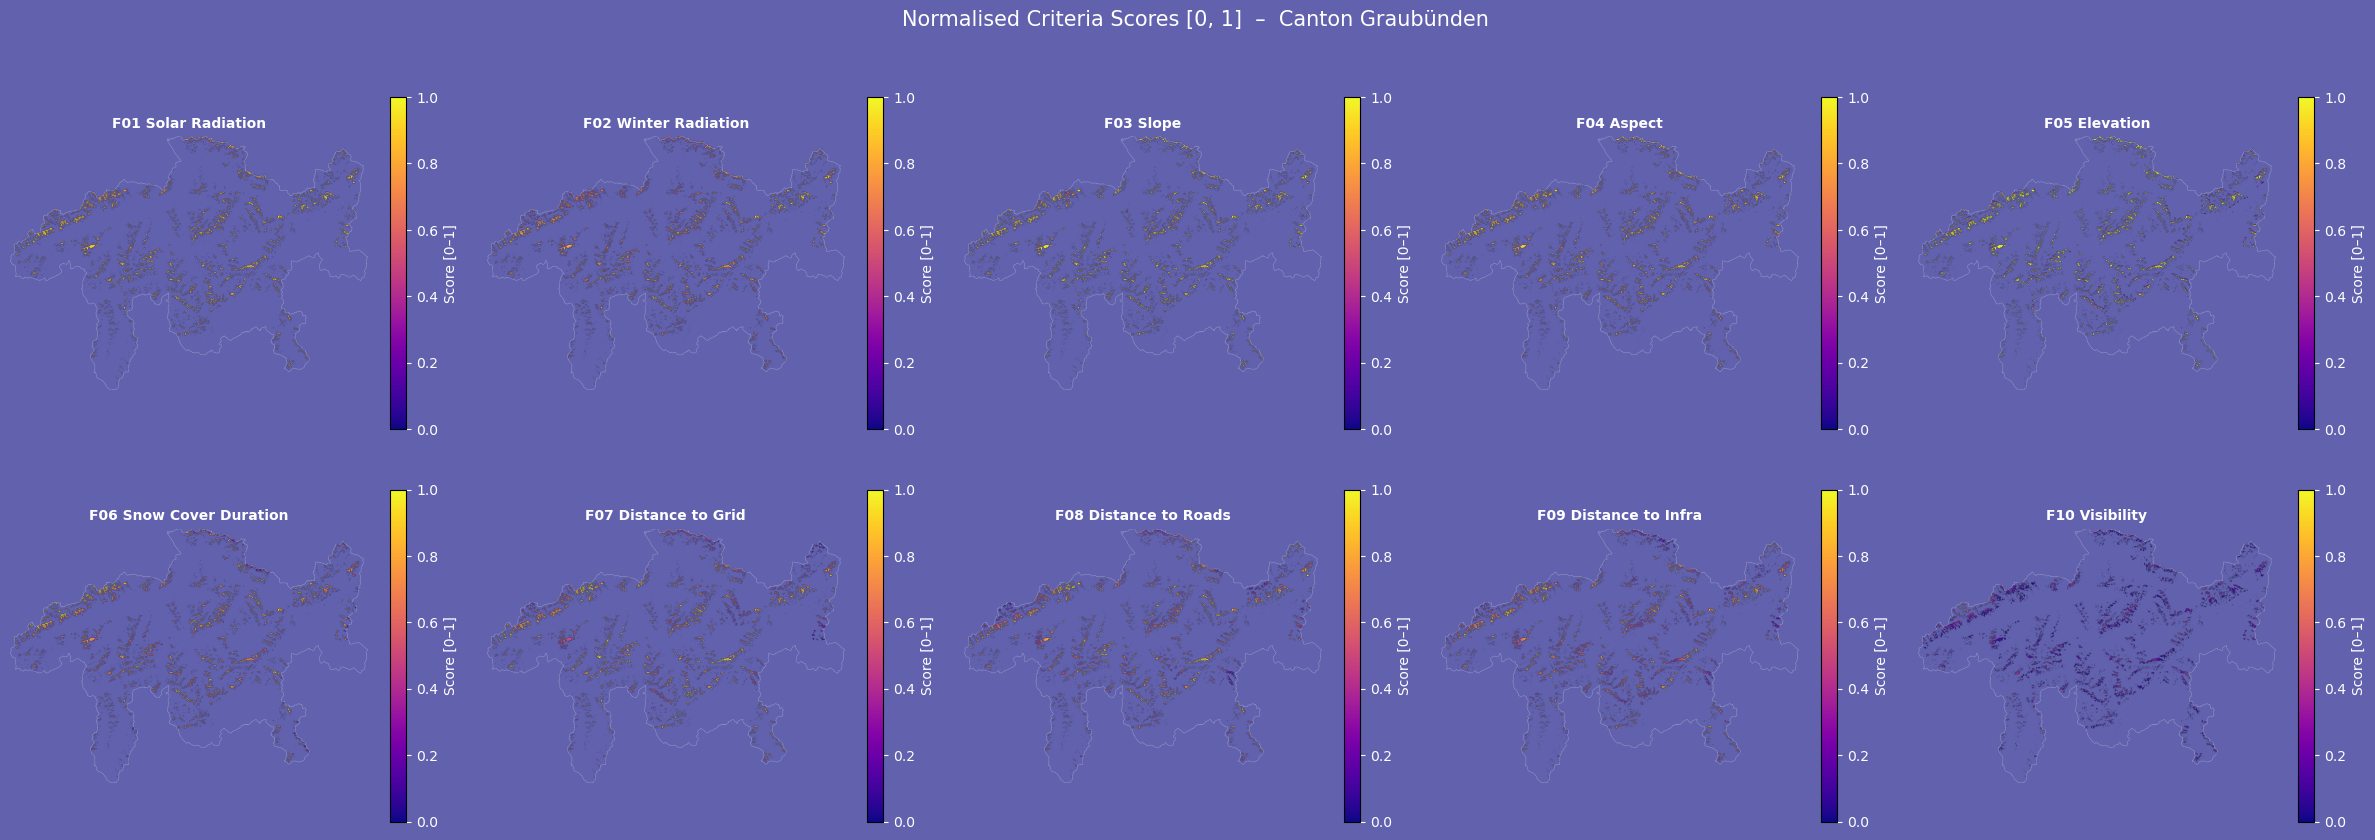

✓ Saved: ..\outputs\figures\criteria_overview.png


In [ ]:
print("=== Overview — Normalized Suitability Factors ===\n")

#All 10 criteria
criteria_files = {
    "F01 Solar Radiation":       "f01_globalstrahlung",
    "F02 Winter Radiation":      "f02_wintereinstrahlung",
    "F03 Slope":                 "f03_hangneigung",
    "F04 Aspect":                "f04_exposition",
    "F05 Elevation":             "f05_hoehenlage",
    "F06 Snow Cover Duration":   "f06_schneebedeckung",
    "F07 Distance to Grid":      "f07_grid_connection",
    "F08 Distance to Roads":     "f08_roads",
    "F09 Distance to Infra":     "f09_infrastructure",
    "F10 Visibility":            "f10_sichtbarkeit",
}

#Canton border for contour
gr_border = gpd.read_file(RAW / "swissboundaries/graubuenden_kantonsgrenze.shp").to_crs(CRS)  # Load GR boundary
inv_tf = ~transform                                                        # Affine inverse: world → pixel

def world_to_pixel(coords):
    """Converts world coordinates to pixel coordinates."""
    arr = np.array(list(coords))  # Convert to array
    xs, ys = arr[:, 0], arr[:, 1]  # Extract x, y
    cols, rows = inv_tf * (xs, ys)  # Transform to pixel space
    return rows, cols

#2×5 overview map
BG_COLOR = "#6161AD"  # Background color
cmap_rg = LinearSegmentedColormap.from_list("cb_safe", ["#D55E00", "#0072B2"], N=256)  # Orange (low) → Blue (high)
fig, axes = plt.subplots(2, 5, figsize=(24, 9), facecolor=BG_COLOR)  # Create subplot grid
fig.suptitle("Normalised Criteria Scores [0, 1]  –  Canton Graubünden", fontsize=15, y=0.98, color="white")

for ax, (label, fname) in zip(axes.flat, criteria_files.items()):  # For each criterion
    ax.set_facecolor(BG_COLOR)  # Set background color
    # Draw canton contour
    for geom in gr_border.geometry:  # For each geometry (handle multipolygons)
        polys = list(geom.geoms) if geom.geom_type == "MultiPolygon" else [geom]  # Convert to list
        for poly in polys:  # For each polygon
            rows, cols = world_to_pixel(poly.exterior.coords)  # Convert to pixel coordinates
            ax.plot(cols, rows, color="white", linewidth=0.4, alpha=0.3)  # Plot boundary

    path = PROC / f"criteria/{fname}.tif"  # File path
    if not path.exists():                                                  # If criterion missing
        ax.set_title(f"{label}\n⚠ missing", fontsize=10, color="white")  # Print warning
        ax.set_axis_off()  # Hide axes
        continue

    with rasterio.open(path) as src:  # Open raster
        data = src.read(1)  # Read band 1
    display = np.where(valid & (data != NODATA), data, np.nan)            # Show only valid pixels
    im = ax.imshow(display, cmap=cmap_rg, vmin=0, vmax=1)  # Display with colorblind-safe colormap
    ax.set_title(label, fontsize=10, fontweight="bold", color="white")  # Title
    ax.set_axis_off()  # Hide axes
    cbar = plt.colorbar(im, ax=ax, label="Score [0–1]", shrink=0.75)      # Add colorbar
    cbar.ax.yaxis.set_tick_params(color="white")  # Colorbar styling
    cbar.ax.yaxis.label.set_color("white")  # Label color
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")  # Tick color

legend_elements = [
    Patch(facecolor="#D55E00", edgecolor="black", label="Low score"),
    Patch(facecolor="#0072B2", edgecolor="black", label="High score"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.03), frameon=True, fancybox=True, shadow=True)
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig(OUT / "criteria_overview.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)  # Save figure
plt.show()  # Display in notebook
print(f"✓ Saved: {OUT / 'criteria_overview.png'}")

## Darstellung Bilder besser Ideen usw?

## 10. MCE Overview — WLC Suitability Factors

In [12]:
print("=== MCE Overview: WLC Suitability Factors ===\n")

#Helper functions
def _ok(p):                                                                # Existence check ✓/✗
    return "✓" if (p is not None and Path(p).exists()) else "✗"  # ✓ if exists, ✗ if missing

def _stats(fname):                                                         # Score statistics from file
    path = PROC / f"criteria/{fname}.tif"  # File path
    if not path.exists():  # If file missing
        return "—", "—"  # Return dashes
    with rasterio.open(path) as src:  # Open raster
        d = src.read(1)  # Read band 1
    v = d[(d != NODATA) & valid]  # Extract valid suitability scores
    return f"{v.mean():.3f}", f"{v.std():.3f}" if v.size else ("—", "—")  # Return mean/std or dashes

#Dynamic source paths
_solar_30 = RAW / "solar/solarenergie-einstrahlung_30_grad_2056.gpkg"  # Solar 30° path
_solar_75 = RAW / "solar/solarenergie-einstrahlung_75_grad_2056.gpkg"  # Solar 75° path
_spass    = sorted((RAW / "snow").glob("**/*.nc"))  # SPASS files
_dem_proc = PROC / "dem/dem_gr_25m.tif"  # Processed DEM
_slope    = PROC / "dem/slope_gr_25m.tif"  # Slope raster
_aspect   = PROC / "dem/aspect_gr_25m.tif"  # Aspect raster

print(f"  BFE Solar 30°:  {_ok(_solar_30)} ({_solar_30.name})")
print(f"  BFE Solar 75°:  {_ok(_solar_75)} ({_solar_75.name})")
print(f"  SPASS Snow:   {_ok(_spass[0]) if _spass else '✗'} ({_spass[0].name if _spass else '—'})")
print(f"  DEM (proc.):    {_ok(_dem_proc)} ({_dem_proc.name})")
print(f"  Slope (proc.):  {_ok(_slope)} ({_slope.name})")
print(f"  Aspect (proc.): {_ok(_aspect)} ({_aspect.name})")
print(f"  swissTLM3D:     {_ok(tlm_path)} ({tlm_path.name})\n")

#All 10 suitability factors (S2 scenario)
wlc = pd.DataFrame([
    {"ID": "F01", "Criterion": "Global Radiation (Annual Sum)",         "Normalization": "Linear [0,1]: (x−min)/(max−min)",                            "Data Source": f"BFE Solar ({_solar_30.name} + {_solar_75.name} → 45° interp.)",  "Format": "Vector → Raster",  "Res.": "200 m",  "Mean": _stats("f01_globalstrahlung")[0],    "Std": _stats("f01_globalstrahlung")[1],    "✓": _ok(PROC / "criteria/f01_globalstrahlung.tif")},
    {"ID": "F02", "Criterion": "Winter Radiation (Oct–Mar)",          "Normalization": "Linear [0,1]: (x−min)/(max−min)",                            "Data Source": f"BFE Solar ({_solar_30.name} + {_solar_75.name} → 45° interp.)",  "Format": "Vector → Raster",  "Res.": "200 m",  "Mean": _stats("f02_wintereinstrahlung")[0], "Std": _stats("f02_wintereinstrahlung")[1], "✓": _ok(PROC / "criteria/f02_wintereinstrahlung.tif")},
    {"ID": "F03", "Criterion": "Slope (Optimum 20–30°)",          "Normalization": "Piecewise: 0→0, 20→1, 30→1, 45→0, 90→0",                   "Data Source": f"DHM25 ({_slope.name})",                                          "Format": "Raster",           "Res.": "25 m",   "Mean": _stats("f03_hangneigung")[0],       "Std": _stats("f03_hangneigung")[1],       "✓": _ok(PROC / "criteria/f03_hangneigung.tif")},
    {"ID": "F04", "Criterion": "Aspect (South Deviation)",            "Normalization": "Linear: S=1.0, N=0.0 (|aspect−180°|)",                       "Data Source": f"DHM25 ({_aspect.name})",                                         "Format": "Raster",           "Res.": "25 m",   "Mean": _stats("f04_exposition")[0],        "Std": _stats("f04_exposition")[1],        "✓": _ok(PROC / "criteria/f04_exposition.tif")},
    {"ID": "F05", "Criterion": "Elevation (Optimum 1800–2500 m)",       "Normalization": "Piecewise: 1500→0, 1800→1, 2500→1, 2700→0",                "Data Source": f"DHM25 ({_dem_proc.name})",                                       "Format": "Raster",           "Res.": "25 m",   "Mean": _stats("f05_hoehenlage")[0],        "Std": _stats("f05_hoehenlage")[1],        "✓": _ok(PROC / "criteria/f05_hoehenlage.tif")},
    {"ID": "F06", "Criterion": "Snow Cover (Reflection Bonus)",     "Normalization": "Linear [0,1]: more snow = better",                         "Data Source": f"SPASS SWE/HS ({_spass[0].name if _spass else '—'})",             "Format": "NetCDF → Raster",  "Res.": "~1 km",  "Mean": _stats("f06_schneebedeckung")[0],   "Std": _stats("f06_schneebedeckung")[1],   "✓": _ok(PROC / "criteria/f06_schneebedeckung.tif")},
    {"ID": "F07", "Criterion": "Distance to Grid (Power Lines)",         "Normalization": "Inverse linear: closer = better",                              "Data Source": f"swissTLM3D ({tlm_path.name}, tlm_bauten_leitung)",               "Format": "Vector → Distance", "Res.": "25 m",   "Mean": _stats("f07_grid_connection")[0],     "Std": _stats("f07_grid_connection")[1],     "✓": _ok(PROC / "criteria/f07_grid_connection.tif")},
    {"ID": "F08", "Criterion": "Distance to Roads (Driveable)",          "Normalization": "Inverse linear: closer = better",                              "Data Source": f"swissTLM3D ({tlm_path.name}, tlm_strassen_strasse)",             "Format": "Vector → Distance", "Res.": "25 m",   "Mean": _stats("f08_roads")[0],           "Std": _stats("f08_roads")[1],           "✓": _ok(PROC / "criteria/f08_roads.tif")},
    {"ID": "F09", "Criterion": "Distance to Infrastructure (Dams)",    "Normalization": "Inverse linear: closer = better",                              "Data Source": f"swissTLM3D ({tlm_path.name}, tlm_bauten_staubaute)",             "Format": "Vector → Distance", "Res.": "25 m",   "Mean": _stats("f09_infrastructure")[0],     "Std": _stats("f09_infrastructure")[1],     "✓": _ok(PROC / "criteria/f09_infrastructure.tif")},
    {"ID": "F10", "Criterion": "Visibility (Settlement Distance)",       "Normalization": "Linear: farther = less visible = better",                 "Data Source": f"swissTLM3D ({tlm_path.name}, tlm_bauten_gebaeude_footprint)",    "Format": "Vector → Distance", "Res.": "25 m",   "Mean": _stats("f10_sichtbarkeit")[0],      "Std": _stats("f10_sichtbarkeit")[1],      "✓": _ok(PROC / "criteria/f10_sichtbarkeit.tif")},
])

#Formatted output
n_ok = (wlc["✓"] == "✓").sum()                                            # Count available outputs
print(f"  Total: {len(wlc)} Factors | {n_ok}/{len(wlc)} Outputs ✓\n")

print(wlc)

=== MCE Overview: WLC Suitability Factors ===

  BFE Solar 30°:  ✓ (solarenergie-einstrahlung_30_grad_2056.gpkg)
  BFE Solar 75°:  ✓ (solarenergie-einstrahlung_75_grad_2056.gpkg)
  SPASS Snow:   ✓ (SWECLQMD_ch01h.swiss.lv95_WY_1962_2023.nc)
  DEM (proc.):    ✓ (dem_gr_25m.tif)
  Slope (proc.):  ✓ (slope_gr_25m.tif)
  Aspect (proc.): ✓ (aspect_gr_25m.tif)
  swissTLM3D:     ✓ (SWISSTLM3D_2026_LV95_LN02.gpkg)

  Total: 10 Factors | 10/10 Outputs ✓

    ID                          Criterion  \
0  F01      Global Radiation (Annual Sum)   
1  F02         Winter Radiation (Oct–Mar)   
2  F03             Slope (Optimum 20–30°)   
3  F04           Aspect (South Deviation)   
4  F05    Elevation (Optimum 1800–2500 m)   
5  F06      Snow Cover (Reflection Bonus)   
6  F07     Distance to Grid (Power Lines)   
7  F08      Distance to Roads (Driveable)   
8  F09  Distance to Infrastructure (Dams)   
9  F10   Visibility (Settlement Distance)   

                               Normalization  \
0     

## Next Step

All suitability factors are available as normalized GeoTIFFs in `data/processed/criteria/`.

**→ Continue with:** `04_wlc.ipynb` → WLC combination (AHP weights × criteria × constraint mask)

**Interface guarantee:** This notebook only requires `constraint_mask_s2.tif` and DEM derivatives from 01/02a as input.